# 손바닥 sEMG 기반 사용자 식별: 재현 및 모델별 성능 비교

문헌정보학과 22127067 김창겸

## 0. 환경 설정

In [ ]:
import os, sys, subprocess

if 'google.colab' in sys.modules and not os.path.exists('data.py'):
    subprocess.run(['git', 'clone', REPO_URL, 'repo'], check=True)
    os.chdir('repo')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'PyWavelets'], check=True)

import numpy as np, torch, scipy, sklearn, pywt, matplotlib
import matplotlib.pyplot as plt
print('python', sys.version.split()[0], '| numpy', np.__version__, '| torch', torch.__version__,
      '| CUDA', torch.cuda.is_available())

python 3.12.10 | numpy 2.5.2 | torch 2.11.0+cu128 | CUDA True


## 1. 데이터 확인

피험자 5명(A~E) × 50시행. 시행마다 3초 × 2채널 × 1000Hz = (3000, 2).

In [2]:
import data as D
from collections import Counter

files = D.list_files()
print('파일 개수:', len(files))
print('피험자별 시행 수:', dict(sorted(Counter(os.path.basename(os.path.dirname(f)) for f in files).items())))

x = D.load(files[0])
print('배열 모양:', x.shape, '| 값 범위:', round(x.min(), 3), '~', round(x.max(), 3))

파일 개수: 250
피험자별 시행 수: {'A': 50, 'B': 50, 'C': 50, 'D': 50, 'E': 50}
배열 모양: (3000, 2) | 값 범위: -3.537 ~ 4.339


## 2. 전처리

60Hz 노치 → 20~499Hz 4차 대역통과(`filtfilt`) → 300ms 윈도우, 150ms 간격 → 윈도우별 min-max 정규화 → Morlet CWT(스케일 1~32).

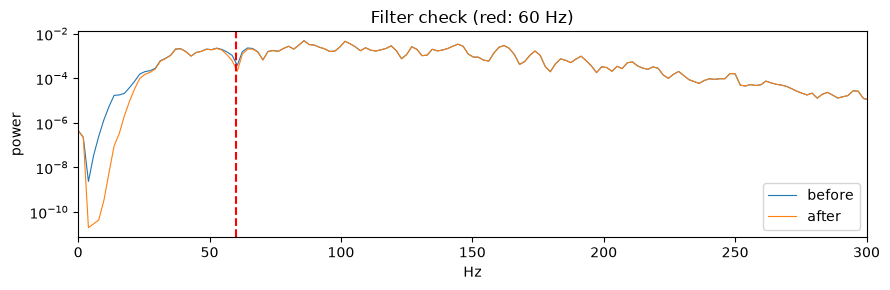

In [3]:
from scipy.signal import welch

xf = D.preprocess(x)
f0, P0 = welch(x[:, 0], fs=D.FS, nperseg=512)
f1, P1 = welch(xf[:, 0], fs=D.FS, nperseg=512)
plt.figure(figsize=(9, 3))
plt.semilogy(f0, P0, label='before', lw=0.8)
plt.semilogy(f1, P1, label='after', lw=0.8)
plt.axvline(60, color='r', ls='--')
plt.xlim(0, 300); plt.legend(); plt.xlabel('Hz'); plt.ylabel('power')
plt.title('Filter check (red: 60 Hz)'); plt.tight_layout(); plt.show()

윈도우 배열: (19, 300, 2)  (19 = (3000 - 300) / 150 + 1)
정규화 후 값 범위: 0.0 ~ 0.9999999987119951
CWT 입력 텐서: (3, 32, 300)


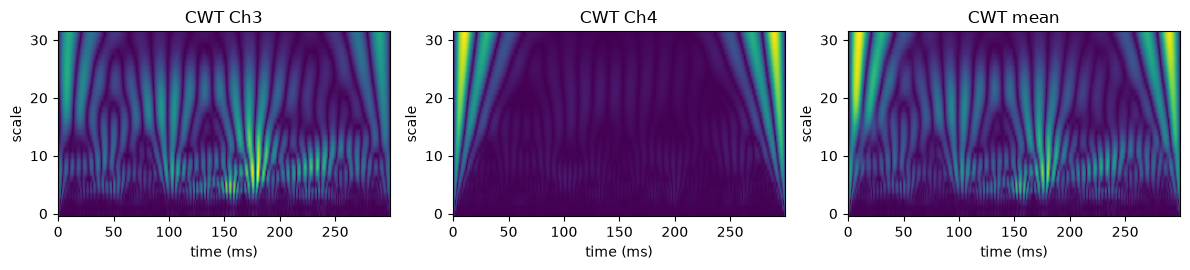

In [4]:
w = D.make_windows(xf)
wn = D.minmax(w)
print('윈도우 배열:', w.shape, ' (19 = (3000 - 300) / 150 + 1)')
print('정규화 후 값 범위:', wn.min(), '~', wn.max())

t = D.to_cwt(wn[6])
print('CWT 입력 텐서:', t.shape)
fig, ax = plt.subplots(1, 3, figsize=(12, 2.8))
for i, title in enumerate(['Ch3', 'Ch4', 'mean']):
    ax[i].imshow(t[i], aspect='auto', origin='lower'); ax[i].set_title(f'CWT {title}')
    ax[i].set_xlabel('time (ms)'); ax[i].set_ylabel('scale')
plt.tight_layout(); plt.show()

## 3. 시행 단위 분할

윈도우는 서로 50% 겹치므로 윈도우 단위로 나누면 같은 신호가 train/test 양쪽에 들어간다.
시행을 먼저 8:2로 나누고, `assert_trial_level`로 겹침이 없음을 검사한다.

In [5]:
tr_ids, te_ids = D.holdout_split(files)
D.assert_trial_level(tr_ids, te_ids)
n_win = len(w)
print(f'train {len(tr_ids)}시행 / test {len(te_ids)}시행  ->  윈도우 {len(tr_ids) * n_win} / {len(te_ids) * n_win}')
print('test 피험자별 시행 수:', dict(sorted(Counter(D.label_of(files[i]) for i in te_ids).items())), '(0=A ... 4=E)')

for a, b in D.cv_splits(files):
    D.assert_trial_level(a, b)
print('5-fold 모두 시행 단위 분할 확인')

train 200시행 / test 50시행  ->  윈도우 3800 / 950
test 피험자별 시행 수: {0: 10, 1: 10, 2: 10, 3: 10, 4: 10} (0=A ... 4=E)
5-fold 모두 시행 단위 분할 확인


## 4. 모델

| 모델 | 입력 |
|---|---|
| DenseNet161 (제안) | CWT (3, 32, 300) |
| ResNet18 | CWT (3, 32, 300) |
| Simple 2D CNN | CWT (3, 32, 300) |
| 1D CNN | 원신호 (2, 300) |
| 1D / 2D CNN (params = paper) | 추가 실험: 파라미터 수를 논문 Table 4에 맞춤 |

In [6]:
from model import MODEL_INPUT, MODEL_LABEL, PAPER_PARAMS, build_model, count_params

for name, kind in MODEL_INPUT.items():
    shape = (2, 3, 32, 300) if kind == 'cwt' else (2, 2, 300)
    m = build_model(name).eval()
    n = count_params(m)
    note = f'  (논문 {PAPER_PARAMS[name]:,}: 일치)' if name in PAPER_PARAMS and n == PAPER_PARAMS[name] else ''
    print(f'{MODEL_LABEL[name]:28s} out={tuple(m(torch.randn(*shape)).shape)}  params={n:,}{note}')

DenseNet161 (proposed)       out=(2, 5)  params=26,483,045
ResNet18                     out=(2, 5)  params=11,179,077
Simple 2D CNN                out=(2, 5)  params=19,717
1D CNN                       out=(2, 5)  params=136,293
1D CNN (params = paper)      out=(2, 5)  params=9,589  (논문 9,589: 일치)
2D CNN (params = paper)      out=(2, 5)  params=4,944,901  (논문 4,944,901: 일치)


## 5. 학습 (선택)

모든 모델이 같은 분할, 45 epoch, Adam(lr 1e-3), 배치 16, CrossEntropyLoss, 시드 42로 학습한다.
전체 실행은 GPU 기준 약 1.5시간이라 기본값은 건너뛰고 저장된 결과(`results/`)를 쓴다.
다시 학습하려면 `RUN_TRAINING = True`로 바꾼다.

In [7]:
RUN_TRAINING = False     # True: main.py 전체 실행 (홀드아웃 -> 누수 점검 -> 오류 분석 -> 5-fold)

if RUN_TRAINING:
    subprocess.run([sys.executable, 'main.py', '--force'], check=True)
else:
    print('학습 건너뜀: results/ 의 저장된 결과를 사용한다.')

학습 건너뜀: results/ 의 저장된 결과를 사용한다.


## 6. 모델별 성능 비교

In [8]:
import json, pandas as pd

R = 'results'
NAMES = {'densenet161': 'DenseNet161 (제안)', 'resnet18': 'ResNet18', 'cnn2d': 'Simple 2D CNN', 'cnn1d': '1D CNN'}
J = lambda f: json.load(open(f'{R}/{f}', encoding='utf-8'))
H = {k: J(f'holdout_{k}.json') for k in NAMES}
CV = {k: J(f'cv_{k}.json') for k in NAMES}
pct = lambda v: round(v * 100, 2)

print('홀드아웃 테스트 성능 (%)  [test 50시행, 윈도우 950개, 1회 실행]')
pd.DataFrame({NAMES[k]: {'Accuracy': pct(h['accuracy']), 'Precision': pct(h['precision']),
                         'Recall': pct(h['recall']), 'F1-score': pct(h['f1'])} for k, h in H.items()}).T

홀드아웃 테스트 성능 (%)  [test 50시행, 윈도우 950개, 1회 실행]


,Accuracy,Precision,Recall,F1-score
DenseNet161 (제안),88.84,89.07,88.84,88.87
ResNet18,89.16,89.37,89.16,89.12
Simple 2D CNN,65.79,65.70,65.79,65.52
1D CNN,95.58,95.94,95.58,95.58


In [9]:
pd.DataFrame({NAMES[k]: {'Train acc (%)': pct(h['train_accuracy']), '시행 단위 정확도 (%)': pct(h['trial_accuracy']),
                         'Parameters': f"{h['n_params']:,}", '학습 시간 (s)': round(h['train_seconds'], 1),
                         '추론 (ms/샘플)': round(h['inference_ms'], 2)} for k, h in H.items()}).T

,Train acc (%),시행 단위 정확도 (%),Parameters,학습 시간 (s),추론 (ms/샘플)
DenseNet161 (제안),99.87,100.0,"26,483,045",732.0,15.63
ResNet18,99.71,100.0,"11,179,077",133.5,1.91
Simple 2D CNN,65.76,86.0,"19,717",27.0,0.21
1D CNN,99.71,100.0,"136,293",31.5,0.49


In [10]:
print('클래스(피험자)별 F1-score (%)')
pd.DataFrame({NAMES[k]: {s: pct(h['per_class'][s]['f1']) for s in D.SUBJECTS} for k, h in H.items()}).T

클래스(피험자)별 F1-score (%)


,A,B,C,D,E
DenseNet161 (제안),98.13,83.78,88.52,87.82,86.08
ResNet18,96.41,86.34,88.12,90.61,84.13
Simple 2D CNN,97.16,57.83,62.40,59.78,50.43
1D CNN,99.47,94.71,94.24,93.85,95.63


In [11]:
print('5-fold 교차검증 정확도 (%)')
rows = {}
for k, c in CV.items():
    r = {f'Fold {f["fold"]}': pct(f['accuracy']) for f in c['folds']}
    r['평균 ± 표준편차'] = f"{pct(c['mean_accuracy']):.2f} ± {pct(c['std_accuracy']):.2f}"
    rows[NAMES[k]] = r
pd.DataFrame(rows).T

5-fold 교차검증 정확도 (%)


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,평균 ± 표준편차
DenseNet161 (제안),81.37,86.84,90.11,89.58,88.0,87.18 ± 3.13
ResNet18,85.68,85.05,89.05,88.32,90.0,87.62 ± 1.93
Simple 2D CNN,69.37,61.89,62.63,61.47,70.74,65.22 ± 3.99
1D CNN,93.37,92.74,92.21,96.95,96.95,94.44 ± 2.08


In [12]:
print('재현성 점검: 같은 설정 반복 시 홀드아웃 정확도 (%)')
S = J('seed_variability.json')['summary']
LAB = {'cnn1d/same_seed': '1D CNN, 같은 시드(42) 5회', 'cnn1d/other_seeds': '1D CNN, 시드 0~4',
       'cnn1d/window_split': '1D CNN, 윈도우 단위 분할(누수), 시드 0~4',
       'resnet18/other_seeds': 'ResNet18, 시드 0~2', 'densenet161/other_seeds': 'DenseNet161, 시드 0~2'}
pd.DataFrame({LAB[k]: {'횟수': f"{v['n']}회", '평균': round(v['mean'], 2), '표준편차': round(v['std'], 2),
                       '최소': round(v['min'], 2), '최대': round(v['max'], 2)} for k, v in S.items()}).T

재현성 점검: 같은 설정 반복 시 홀드아웃 정확도 (%)


,횟수,평균,표준편차,최소,최대
"1D CNN, 같은 시드(42) 5회",5회,93.85,2.63,88.84,96.11
"1D CNN, 시드 0~4",5회,85.56,12.2,61.68,95.89
"1D CNN, 윈도우 단위 분할(누수), 시드 0~4",5회,84.78,10.21,66.95,97.68
"ResNet18, 시드 0~2",3회,88.11,2.09,85.16,89.79
"DenseNet161, 시드 0~2",3회,89.54,0.65,88.74,90.32


In [13]:
print('추가 실험: 파라미터 수를 논문에 맞춘 1D·2D CNN (%)')
PM = {'cnn1d_pm': '1D CNN (params = paper)', 'cnn2d_pm': '2D CNN (params = paper)'}
seeds = J('param_matched_seeds.json')
rows = {}
for k, lab in PM.items():
    h, c = J(f'holdout_{k}.json'), J(f'cv_{k}.json')
    a = np.array([r['accuracy'] for r in seeds if r['model'] == k]) * 100
    rows[lab] = {'Parameters': f"{h['n_params']:,}", '홀드아웃 Acc': pct(h['accuracy']),
                 '5-fold Acc': f"{pct(c['mean_accuracy']):.2f} ± {pct(c['std_accuracy']):.2f}",
                 '시드 0~4 평균 ± 표준편차': f'{a.mean():.2f} ± {a.std():.2f} ({a.min():.2f}~{a.max():.2f})'}
pd.DataFrame(rows).T

추가 실험: 파라미터 수를 논문에 맞춘 1D·2D CNN (%)


,Parameters,홀드아웃 Acc,5-fold Acc,시드 0~4 평균 ± 표준편차
1D CNN (params = paper),"9,589",96.11,85.85 ± 5.48,80.36 ± 13.27 (55.47~94.74)
2D CNN (params = paper),"4,944,901",82.11,81.56 ± 2.61,80.86 ± 0.83 (79.37~81.68)


## 7. Confusion Matrix (혼동행렬)

행은 실제, 열은 예측이며, 클래스당 test 윈도우 190개이다.

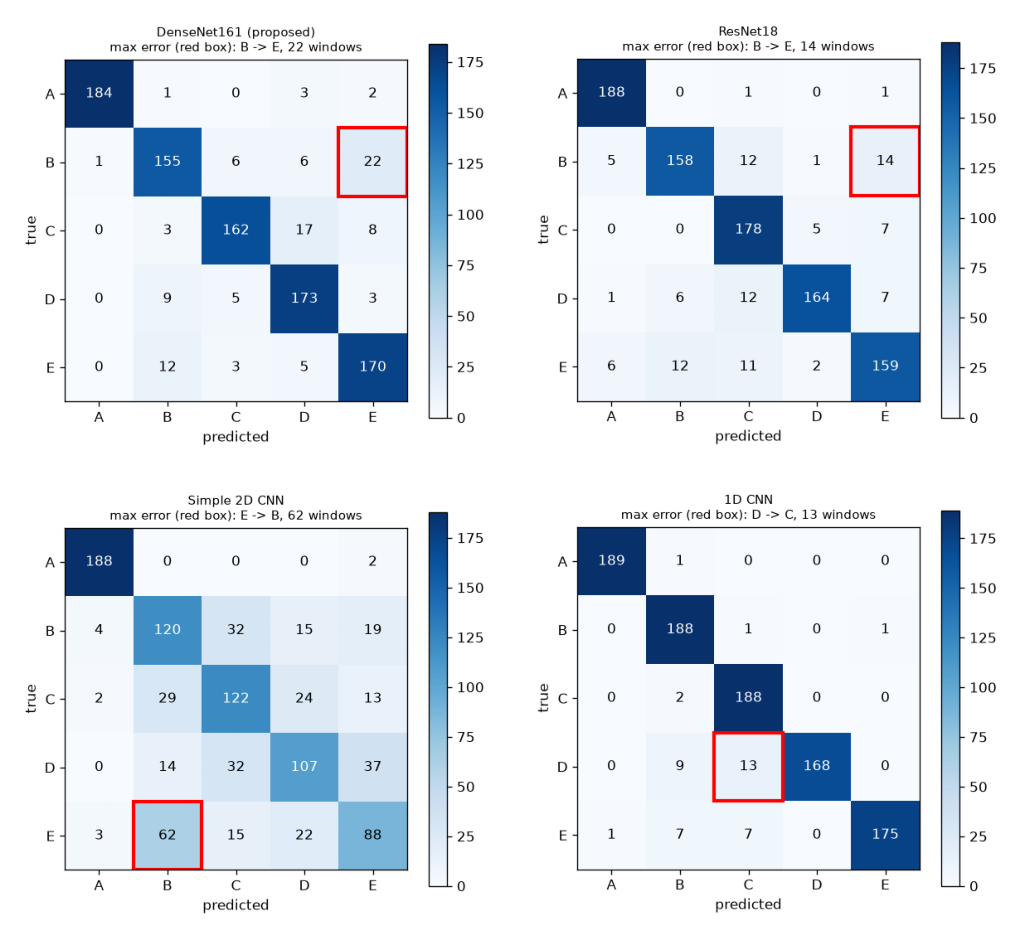

DenseNet161 (제안)     최대 오류 쌍: B -> E (22개)
ResNet18             최대 오류 쌍: B -> E (14개)
Simple 2D CNN        최대 오류 쌍: E -> B (62개)
1D CNN               최대 오류 쌍: D -> C (13개)


In [14]:
import matplotlib.image as mpimg

def show(files, ncols=2, w=5.2):
    nrows = -(-len(files) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, w * 0.92 * nrows))
    for ax in np.ravel(axes):
        ax.axis('off')
    for ax, f in zip(np.ravel(axes), files):
        ax.imshow(mpimg.imread(f))
    plt.tight_layout(); plt.show()

show([f'{R}/confusion_matrix_{k}.png' for k in NAMES])
for k, h in H.items():
    p = h['max_error_pair']
    print(f"{NAMES[k]:20s} 최대 오류 쌍: {p['true']} -> {p['pred']} ({p['count']}개)")

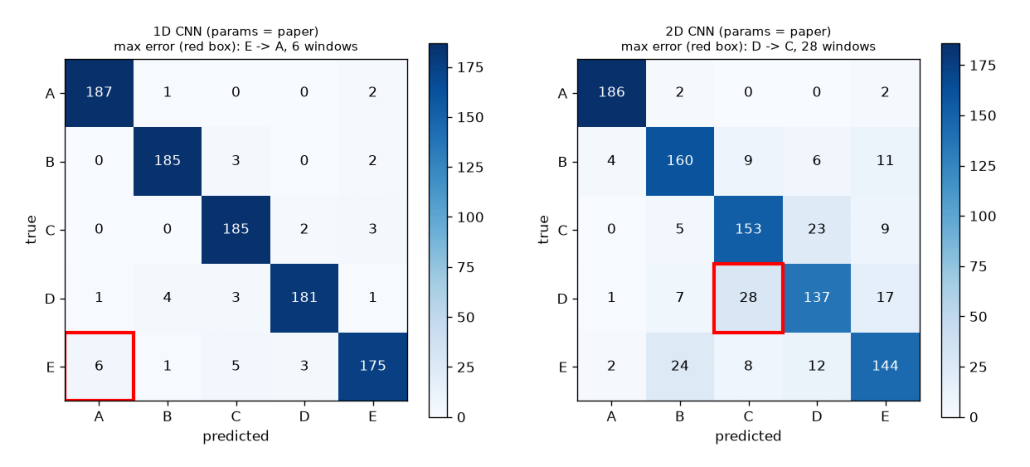

In [15]:
show([f'{R}/confusion_matrix_{k}.png' for k in PM])

## 8. 오류 분석

- 두 채널 크기 비율(Ch3/Ch4)이 피험자마다 다르고, 비율이 비슷한 쌍(B–E 등)일수록 더 자주 헷갈렸다.
- 오류는 신호가 약한 구간에 몰리지 않았다.

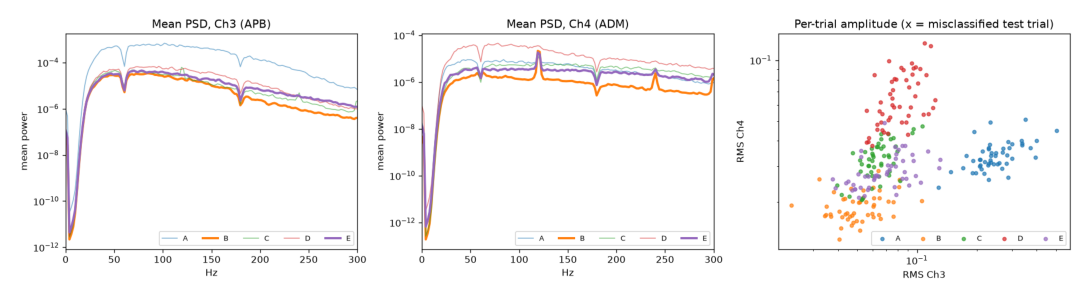

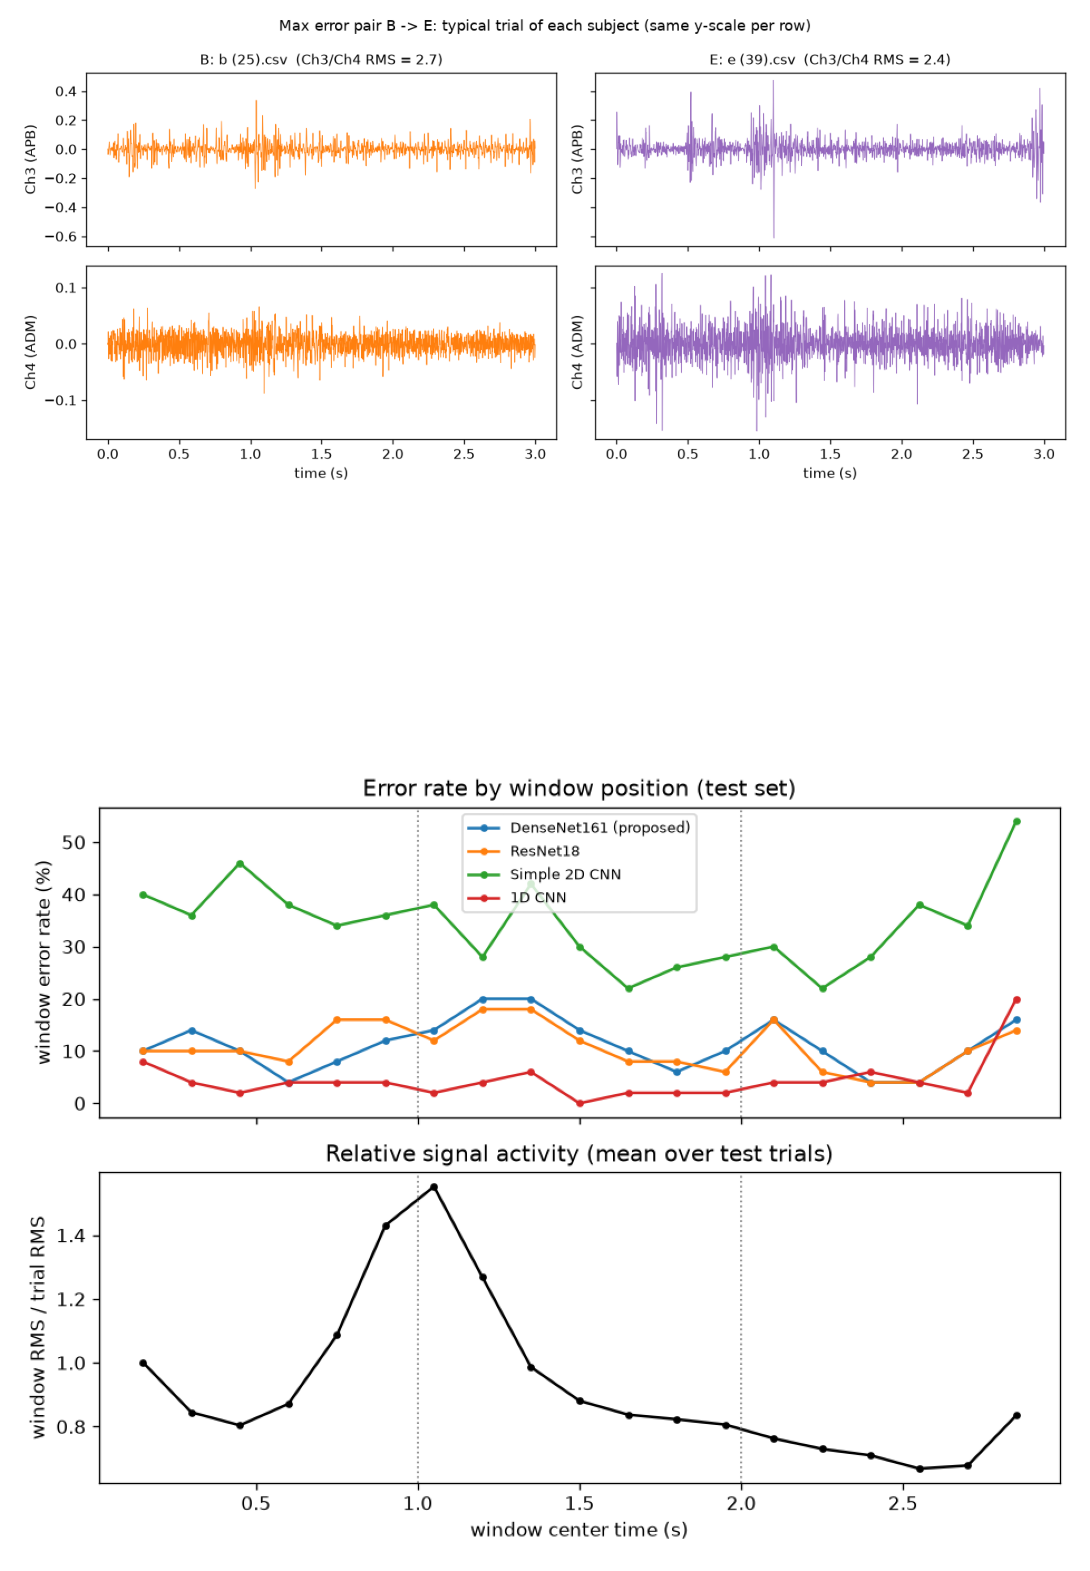

In [16]:
show([f'{R}/error_analysis.png'], ncols=1, w=11)
show([f'{R}/pair_waveforms.png', f'{R}/error_by_position.png'], ncols=1, w=11)

In [17]:
print(open(f'{R}/pair_similarity.md', encoding='utf-8').read())

### 피험자 쌍의 특징 차이와 혼동 횟수의 Spearman 상관 (ρ, p; 쌍 10개)

| Model | Ch3/Ch4 비율(log) | RMS Ch3(log) | RMS Ch4(log) | 중앙주파수 Ch3 | 중앙주파수 Ch4 |
|---|---|---|---|---|---|
| DenseNet161 (proposed) | -0.79 (0.007) | -0.63 (0.053) | +0.36 (0.300) | -0.06 (0.868) | -0.13 (0.725) |
| ResNet18 | -0.96 (0.000) | -0.75 (0.012) | -0.04 (0.920) | -0.17 (0.637) | +0.16 (0.649) |
| Simple 2D CNN | -0.85 (0.002) | -0.65 (0.043) | +0.24 (0.511) | -0.31 (0.385) | +0.25 (0.489) |
| 1D CNN | -0.65 (0.041) | -0.33 (0.358) | +0.22 (0.538) | +0.18 (0.610) | +0.01 (0.987) |

### 쌍별 혼동 횟수 (양방향 합, 윈도우)

| Model | AB | AC | AD | AE | BC | BD | BE | CD | CE | DE |
|---|---|---|---|---|---|---|---|---|---|---|
| DenseNet161 (proposed) | 2 | 0 | 3 | 2 | 9 | 15 | 34 | 22 | 11 | 8 |
| ResNet18 | 5 | 1 | 1 | 7 | 12 | 7 | 26 | 17 | 18 | 9 |
| Simple 2D CNN | 4 | 2 | 0 | 5 | 61 | 29 | 81 | 56 | 28 | 59 |
| 1D CNN | 1 | 0 | 0 | 1 | 3 | 9 | 8 | 13 | 7 | 0 |

### 피험자별 평균 (전체 시행)

| 특징 | A | B | C | D | E |
|---|---|---|---|---|---

## 9. 최종 결과

- 가장 성능이 좋은 모델: 1D CNN. 홀드아웃 F1 95.58%, 5-fold 평균 94.44%이고 5개 폴드 모두 DenseNet161·ResNet18보다 높았다.
- 가장 성능이 낮은 모델: Simple 2D CNN. 홀드아웃 65.79%, 5-fold 65.22%이고 train accuracy도 65.76%라 학습이 되지 않았다.
- 주요 오분류 클래스: B와 E. 같은 B–E 쌍이 DenseNet161 34건, ResNet18 26건, 2D CNN 81건으로 가장 많이 헷갈렸고 C와 D가 뒤를 이었다.
- 전체적인 실험 결과 및 느낀 점: 첫 구동에서 논문과 많이 다른 결과값이 나와서 놀랐다. 단순 따라하는 경우에서 DenseNet161이 제일 좋게 나올거라 예상했지만 1D CNN이 제일 좋게 나왔다. 그 다음은 2D CNN이 논문과 너무나도 큰 차이점을 보였다. 이후 수정을 거듭하여 논문의 내용과는 낮은 수치지만 차이를 많이 줄였다. AI한테 물어본 결과 PDF에 있는 코드와 실제 논문이 사용한 2D CNN이 다르기 때문이라고 했다. 표면적으로 생각한 CNN이 다양하게 존재한다는 것을 깨달았다. 이후 혼동값에서도 차이점이 있다. 학습예열이 안되었거나, 피라미터가 제대로 설정이 안되었는지 확인했다. 다만, 똑같은 값으로 설정되어 있었으며, 결과가 달랐다. 이번 과제가 끝나고도 계속 의문으로 들어있을거같다.